# Metric calibration

Before the metrics are used to assess the predictions, this notebook establishes how their values are
read. It verifies the implementation against Machaon's own procedure, measures how the metrics respond
to factors other than conformation (missing residues, the orientation of a structure in space and the
presence of hydrogen atoms), and sets three reference levels: copies of a protein within one entry,
models of one NMR ensemble, and structures determined by different methods.

**Input:** `results/comparisons.json` from notebook 02; sections 1 and 2 and the entry copies also read
the structure files in `data/`. Slow steps are cached in `results/` (set `RECOMPUTE = True` to repeat
them).  
**Output:** `results/reference_levels.csv`, `results/calibration_summary.json`,
`results/t_alpha_pca.csv`, `results/entry_copies.json` and the figures in `results/figures/`.

In [1]:
import contextlib
import io
import json
import os
import sys
import warnings

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import src.dataset as ds
from src.analysis import protein_table
from src.baselines import (
    LEVEL_ORDER,
    baseline_levels,
    compare_entry_copies,
    coverage_dependence,
    coverage_frame,
    find_entry_copies,
    method_pair_table,
    pair_medians_by_coverage,
    reference_levels_table,
    summarise_copies,
)
from src.figures import COLOR, LABEL, apply_style, log_floor, positive, save

apply_style()
RECOMPUTE = (
    False  # True: redo the cached copies, orientation floor and principal-axes t-alpha
)

with open("results/comparisons.json") as f:
    records = [r for r in json.load(f) if r.get("status") == "ok"]
manifest = pd.read_csv("proteins.csv", dtype=str, keep_default_na=False)
table = protein_table(records)
pairs = method_pair_table(records)
EXP_PAIRS = ["X-ray–NMR", "X-ray–Cryo-EM", "NMR–Cryo-EM"]
summary = {}  # numbers for the reading at the end (results/calibration_summary.json)


def exp_path(pdb_id):
    return f"data/experimental/{pdb_id.upper()}.cif"


HAVE_STRUCTURES = any(os.path.exists(exp_path(p)) for p in manifest["pdb_nmr"] if p)
n_ens = sum(r["category"] == "nmr_intra_ensemble" for r in records)
print(
    f"{len(records)} comparison records ({len(records) - n_ens} between structures, {n_ens} inside NMR "
    f"ensembles) | {len(table)} proteins | structure files present: {HAVE_STRUCTURES}"
)

# proteins for the single-structure checks: the first N_CHECK with NMR and cryo-EM files on disk
N_CHECK = 5
check_rows = [
    r
    for _, r in manifest.iterrows()
    if r["pdb_nmr"]
    and r["pdb_cryoem"]
    and os.path.exists(exp_path(r["pdb_nmr"]))
    and os.path.exists(exp_path(r["pdb_cryoem"]))
][:N_CHECK]
print("single-structure checks on:", [r["protein_name"][:40] for r in check_rows])
# X-ray chains carry most alternate conformations: the Machaon cross-check also uses X-ray–cryo-EM pairs
xray_rows = [
    r
    for _, r in manifest.iterrows()
    if r["pdb_xray"]
    and r["pdb_cryoem"]
    and os.path.exists(exp_path(r["pdb_xray"]))
    and os.path.exists(exp_path(r["pdb_cryoem"]))
][:N_CHECK]

3477 comparison records (1266 between structures, 2211 inside NMR ensembles) | 151 proteins | structure files present: True
single-structure checks on: ['Type IV pilin PilE1', 'Toxin co-regulated pilus biosynthesis pr', 'ATP synthase epsilon chain (B1MLW3)', 'Type II secretion system core protein G', 'Acyl carrier protein, mitochondrial']


---
## 1. The metrics compare summaries, not residues

Machaon reduces each structure to three summaries computed from that structure alone — its (φ, ψ)
angles fitted as a 2-D Gaussian, the distribution of all its Cα–Cα distances, and the number of
triangles of an alpha shape over its atoms — and compares two structures only through these
summaries. No residue of one structure is paired with a residue of the other: the two may differ in
length and sequence, and the summaries are computed once per structure, which is what makes a
search over a whole database cheap. RMSD, in contrast, needs every residue paired with its
counterpart.

**1a.** `src/machaon_reference.py` repeats Machaon's feature extraction as literally as possible
(Biopython, min-max scaling, Open3D alpha shape) and Machaon's three formulas; the table compares it
with `src/metrics.py` on NMR–cryo-EM and X-ray–cryo-EM pairs of a few proteins (X-ray chains often
contain alternate conformations, which both must reduce to one per atom). Expected: differences at
rounding level for b-phipsi, w-rdist and "t_alpha (all atoms, Machaon)". The heavy-atom row differs
when a file contains hydrogens — the one deliberate deviation, measured in section 2c.

In [2]:
from src.machaon_reference import compare_with_pipeline, count_chain_breaks
from src.nmr import choose_nmr_model

xcheck = []
pairs_to_check = [("NMR", "pdb_nmr", "chain_nmr", r) for r in check_rows] + [
    ("X-ray", "pdb_xray", "chain_xray", r) for r in xray_rows
]
for method, pdb_col, chain_col, r in pairs_to_check:
    file_a, em_file = exp_path(r[pdb_col]), exp_path(r["pdb_cryoem"])
    model = (
        choose_nmr_model(file_a, r[chain_col], "medoid")["model"]
        if method == "NMR"
        else 0
    )
    t = compare_with_pipeline(
        file_a, r[chain_col], em_file, r["chain_cryoem"], model_a=model
    )
    t.insert(0, "pair", f"{method}–cryo-EM")
    t.insert(0, "protein", r["protein_name"][:30])
    t["chain_breaks"] = count_chain_breaks(
        file_a, r[chain_col], model
    ) + count_chain_breaks(em_file, r["chain_cryoem"])
    xcheck.append(t)
if xcheck:
    xcheck = pd.concat(xcheck, ignore_index=True)
    display(xcheck)
    machaon_rows = ~xcheck["metric"].str.contains("heavy")
    summary["machaon_max_abs_diff"] = float(
        xcheck.loc[machaon_rows, "abs_diff"].astype(float).max()
    )
    print(
        f"largest difference from Machaon's procedure (b-phipsi, w-rdist, t-alpha with all atoms): "
        f"{summary['machaon_max_abs_diff']:.1e}"
    )
else:
    print("skipped: no structure files in data/experimental")

,protein,pair,metric,pipeline,reference,abs_diff,chain_breaks
0,Type IV pilin PilE1,NMR–cryo-EM,b_phipsi,0.026923,0.026923,1.414339e-07,1
1,Type IV pilin PilE1,NMR–cryo-EM,w_rdist_norm,1.156810,1.156810,8.482824e-09,1
2,Type IV pilin PilE1,NMR–cryo-EM,"t_alpha (heavy atoms, pipeline)",0.083691,0.148218,6.452665e-02,1
3,Type IV pilin PilE1,NMR–cryo-EM,"t_alpha (all atoms, Machaon)",0.148218,0.148218,0.000000e+00,1
4,Toxin co-regulated pilus biosy,NMR–cryo-EM,b_phipsi,0.025158,0.025158,1.727132e-07,0
5,Toxin co-regulated pilus biosy,NMR–cryo-EM,w_rdist_norm,0.718442,0.718442,6.359169e-09,0
6,Toxin co-regulated pilus biosy,NMR–cryo-EM,"t_alpha (heavy atoms, pipeline)",0.025316,0.283951,2.586342e-01,0
7,Toxin co-regulated pilus biosy,NMR–cryo-EM,"t_alpha (all atoms, Machaon)",0.283951,0.283951,0.000000e+00,0
8,ATP synthase epsilon chain (B1,NMR–cryo-EM,b_phipsi,0.004428,0.004428,5.172319e-08,0
9,ATP synthase epsilon chain (B1,NMR–cryo-EM,w_rdist_norm,0.178707,0.178707,3.374943e-07,0


largest difference from Machaon's procedure (b-phipsi, w-rdist, t-alpha with all atoms): 3.4e-07


**1b. Order of residues.** Shuffle the residues of one chain (its Cα coordinates, its (φ, ψ) pairs and
its atoms, each permuted at random) and compare it with the original. The summaries are unchanged,
so the three metrics stay at 0; RMSD, which pairs residue *i* with residue *i*, becomes large. This
is the sense in which the metrics need no correspondence — and also why a value of 0 means "same
summary", not "same structure".

In [3]:
from src.metrics import (
    _kabsch_rmsd,
    compute_all_metrics,
    summarise_structure,
    summary_from_arrays,
)
from src.parser import get_all_atom_coords, get_phi_psi_with_index, load_structure

if check_rows:
    r = check_rows[0]
    path, chain = exp_path(r["pdb_cryoem"]), r["chain_cryoem"]
    original = summarise_structure(path, 0, chain)
    structure = load_structure(path)
    angles, _ = get_phi_psi_with_index(structure, 0, chain)
    atoms = get_all_atom_coords(structure, 0, chain)
    rng = np.random.default_rng(0)
    shuffled = summary_from_arrays(
        original.ca[rng.permutation(len(original.ca))],
        original.seq,
        angles[rng.permutation(len(angles))],
        atoms[rng.permutation(len(atoms))],
    )
    m = compute_all_metrics(original, shuffled)
    summary["shuffle_rmsd"] = float(_kabsch_rmsd(original.ca, shuffled.ca))
    summary["shuffle_max_metric"] = float(
        max(m["w_rdist_norm"], abs(m["b_phipsi"]), m["t_alpha"])
    )
    print(f"{r['protein_name']} — {r['pdb_cryoem']} chain {chain}, residues shuffled:")
    print(
        f"  w-rdist {m['w_rdist_norm']:.1g}   b-phipsi {abs(m['b_phipsi']):.1g}   t-alpha {m['t_alpha']:.1g}"
    )
    print(f"  RMSD pairing residue i with residue i: {summary['shuffle_rmsd']:.1f} Å")
else:
    print("skipped: no structure files in data/experimental")

Type IV pilin PilE1 — 8PFB chain C, residues shuffled:
  w-rdist 0   b-phipsi 6e-32   t-alpha 0
  RMSD pairing residue i with residue i: 35.5 Å


---
## 2. What changes the metrics besides the conformation

Because the metrics summarise whole structures, anything that changes the summary changes the value,
whether or not the conformation differs. Three such factors are present in this dataset.

### 2a. Coverage: residues present in one chain but not in the other

Two experimental chains of one protein rarely contain exactly the same residues (disordered ends are
not modelled, constructs differ), and the dataset admits chains that model ≥ 80 % of the mature
chain. **Truncation:** remove 0–30 % of a chain's residues (half from each end) and compare the
shortened chain with the whole one — nothing is aligned. The dashed line is the median NMR–cryo-EM
distance of the dataset: where a curve crosses it, missing residues alone are as large as the typical
difference between methods.

,protein,fraction_removed,n_residues,w_rdist_norm,b_phipsi,t_alpha,t_alpha_pca
0,Type IV pilin PilE1,0.00,131,0.0000,0.0000,0.0000,0.0000
1,Type IV pilin PilE1,0.05,124,0.4418,0.0002,0.0837,0.0373
2,Type IV pilin PilE1,0.10,118,0.6472,0.0003,0.0991,0.0730
3,Type IV pilin PilE1,0.20,105,0.8879,0.0020,0.0567,0.0435
4,Type IV pilin PilE1,0.30,92,1.0479,0.0011,0.1524,0.0378
5,Toxin co-regulated pilus biosy,0.00,111,0.0000,0.0000,0.0000,0.0000
6,Toxin co-regulated pilus biosy,0.05,105,0.4514,0.0002,0.0346,0.0059
7,Toxin co-regulated pilus biosy,0.10,100,0.5742,0.0008,0.0444,0.0350
8,Toxin co-regulated pilus biosy,0.20,89,0.8217,0.0323,0.0395,0.0292
9,Toxin co-regulated pilus biosy,0.30,78,0.9607,0.0927,0.0321,0.0533


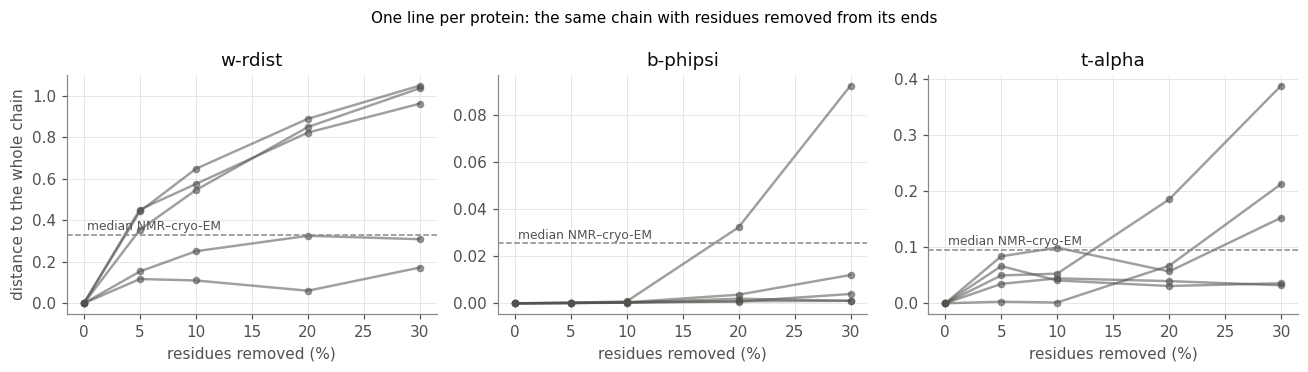

In [4]:
from src.sensitivity import truncation_experiment

trunc = []
for r in check_rows:
    t = truncation_experiment(exp_path(r["pdb_cryoem"]), r["chain_cryoem"])
    t.insert(0, "protein", r["protein_name"][:30])
    trunc.append(t)
if trunc:
    trunc = pd.concat(trunc, ignore_index=True)
    trunc.to_csv("results/truncation.csv", index=False)
    display(trunc.round(4))
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
    for ax, metric in zip(axes, ["w_rdist_norm", "b_phipsi", "t_alpha"]):
        for _, g in trunc.groupby("protein"):
            ax.plot(
                g["fraction_removed"] * 100,
                g[metric],
                marker="o",
                markersize=4,
                color=COLOR["between methods"],
                alpha=0.55,
            )
        reference = pairs.loc["NMR–Cryo-EM", metric]
        ax.axhline(reference, color=COLOR["rule"], lw=1, ls="--")
        ax.annotate(
            "median NMR–cryo-EM",
            (0, reference),
            xytext=(2, 3),
            textcoords="offset points",
            fontsize=8,
            color=COLOR["muted"],
        )
        ax.set_xlabel("residues removed (%)")
        ax.set_title(LABEL[metric])
    axes[0].set_ylabel("distance to the whole chain")
    fig.suptitle(
        "One line per protein: the same chain with residues removed from its ends",
        fontsize=10,
    )
    fig.tight_layout()
    save(fig, "truncation")
    five = trunc[trunc["fraction_removed"] == 0.05]
    summary["truncation_5pct_w_rdist_median"] = float(five["w_rdist_norm"].median())
else:
    print("skipped: no structure files in data/experimental")

**Across the dataset.** If missing residues matter, the distance of a pair should follow its *length
gap* (the share of the longer chain that the shorter one lacks). The table gives the Spearman
correlation of each metric with the length gap, per comparison category. RMSD is computed on
matched residues only, so its correlation is the reference: what RMSD shows is conformation, what the
whole-chain metrics show beyond it is coverage. The second table repeats the experimental-pair
medians using only pairs whose lengths differ by at most 10 % or 5 %.

Spearman ρ between each metric and the length gap of the pair (pairs as points):


metric,w_rdist_norm,b_phipsi,t_alpha,rmsd
category,,,,
exp_vs_exp,0.57,0.21,0.08,0.30
exp_vs_af2,0.71,0.26,0.20,-0.02
exp_vs_of3,0.66,0.22,0.18,-0.03


Median over proteins, experimental pairs, by the largest length gap allowed:


,max_gap,pair,n_proteins,rmsd,w_rdist_norm,b_phipsi,t_alpha
0,all,X-ray–NMR,90,2.930,0.226,0.026,0.117
1,all,X-ray–Cryo-EM,90,1.139,0.163,0.007,0.081
2,all,NMR–Cryo-EM,151,4.498,0.329,0.025,0.095
3,0.1,X-ray–NMR,69,2.385,0.179,0.017,0.115
4,0.1,X-ray–Cryo-EM,84,1.139,0.143,0.007,0.077
5,0.1,NMR–Cryo-EM,116,3.826,0.206,0.024,0.087
6,0.05,X-ray–NMR,57,2.385,0.148,0.015,0.115
7,0.05,X-ray–Cryo-EM,65,0.937,0.126,0.007,0.085
8,0.05,NMR–Cryo-EM,83,3.436,0.172,0.022,0.091


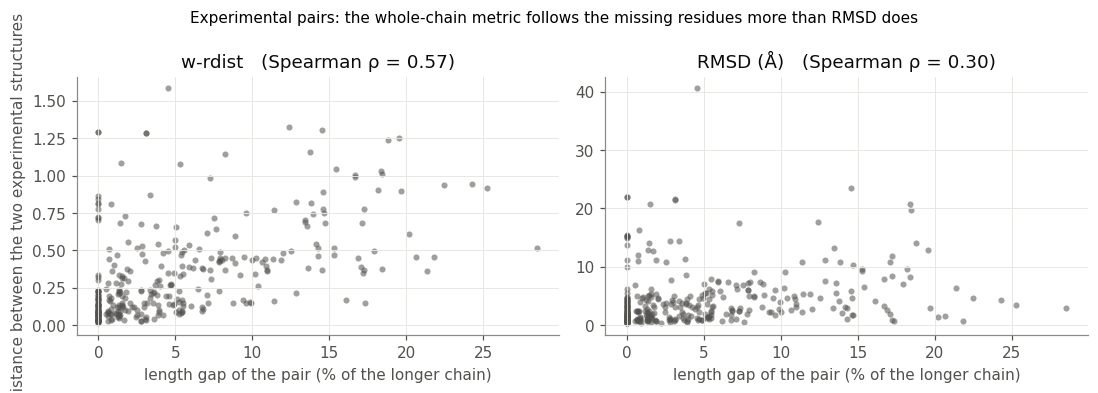

NMR–cryo-EM median w-rdist: 0.329 over all pairs, 0.172 over pairs with ≤ 5 % length gap (RMSD 4.50 → 3.44 Å)


In [5]:
dependence = coverage_dependence(records)
rho = dependence.pivot(index="category", columns="metric", values="rho")
rho = rho.loc[
    ["exp_vs_exp", "exp_vs_af2", "exp_vs_of3"],
    ["w_rdist_norm", "b_phipsi", "t_alpha", "rmsd"],
]
print(
    "Spearman ρ between each metric and the length gap of the pair (pairs as points):"
)
display(rho.round(2))

matched = pair_medians_by_coverage(records)
matched.to_csv("results/coverage_matched_pairs.csv", index=False)
print("Median over proteins, experimental pairs, by the largest length gap allowed:")
display(matched.round(3))

frame = coverage_frame(records)
exp_pairs = frame[frame["category"] == "exp_vs_exp"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, metric in zip(axes, ["w_rdist_norm", "rmsd"]):
    sub = exp_pairs[["length_gap", metric]].dropna()
    ax.scatter(
        sub["length_gap"] * 100,
        sub[metric],
        s=16,
        color=COLOR["between methods"],
        alpha=0.55,
        linewidths=0,
    )
    ax.set_xlabel("length gap of the pair (% of the longer chain)")
    ax.set_title(
        f"{LABEL[metric]}   (Spearman ρ = {rho.loc['exp_vs_exp', metric]:.2f})"
    )
axes[0].set_ylabel("distance between the two experimental structures")
fig.suptitle(
    "Experimental pairs: the whole-chain metric follows the missing residues more than RMSD does",
    fontsize=10,
)
fig.tight_layout()
save(fig, "coverage_dependence")

all_pairs = matched[
    (matched["max_gap"] == "all") & (matched["pair"] == "NMR–Cryo-EM")
].iloc[0]
tight = matched[(matched["max_gap"] == 0.05) & (matched["pair"] == "NMR–Cryo-EM")].iloc[
    0
]
summary.update(
    rho_w_rdist_exp=float(rho.loc["exp_vs_exp", "w_rdist_norm"]),
    rho_rmsd_exp=float(rho.loc["exp_vs_exp", "rmsd"]),
    rho_w_rdist_af2=float(rho.loc["exp_vs_af2", "w_rdist_norm"]),
    rho_rmsd_af2=float(rho.loc["exp_vs_af2", "rmsd"]),
    nmr_cryoem_w_rdist_all=float(all_pairs["w_rdist_norm"]),
    nmr_cryoem_w_rdist_matched=float(tight["w_rdist_norm"]),
    nmr_cryoem_rmsd_all=float(all_pairs["rmsd"]),
    nmr_cryoem_rmsd_matched=float(tight["rmsd"]),
)
print(
    f"NMR–cryo-EM median w-rdist: {summary['nmr_cryoem_w_rdist_all']:.3f} over all pairs, "
    f"{summary['nmr_cryoem_w_rdist_matched']:.3f} over pairs with ≤ 5 % length gap "
    f"(RMSD {summary['nmr_cryoem_rmsd_all']:.2f} → {summary['nmr_cryoem_rmsd_matched']:.2f} Å)"
)

### 2b. Orientation: t-alpha depends on how the structure lies in space

Machaon scales each coordinate axis to [0, 1] before building the alpha shape (scikit-learn's
`MinMaxScaler` in its `pdbhandler.py`; `_minmax_normalize` here). The bounding box of a structure,
and with it the scaling, depends on the orientation of the structure in the file's coordinate frame,
which is arbitrary (crystal axes, map axes, a prediction's own frame). So the same chain, only
rotated, gets t-alpha > 0 against itself. Each sampled chain below is compared with 20 random
rotations of itself, in Machaon's frame and after rotating it onto its principal axes (which makes the
scaling independent of the orientation). The values in Machaon's frame are the **noise floor** of
t-alpha: a t-alpha between two structures that is not larger than this is not evidence of a different
surface.

,n_atoms,raw_median,raw_max,pca_max
method,,,,
Cryo-EM,810.0,0.074,0.211,0.0
NMR,849.0,0.070,0.183,0.0
X-ray,928.0,0.076,0.229,0.0


45 chains × 20 rotations: t-alpha of a chain against itself, median 0.074 (largest 0.55) in Machaon's frame, 0 in the principal-axes frame; median t-alpha between methods: 0.095


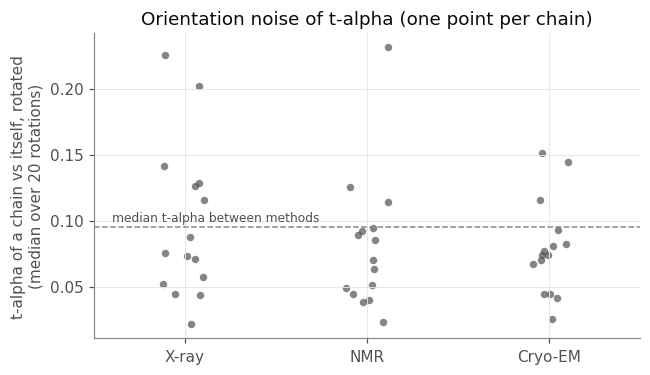

In [6]:
from src.sensitivity import orientation_floor, sample_chains

FLOOR_CSV = "results/orientation_floor.csv"
if os.path.exists(FLOOR_CSV) and not RECOMPUTE:
    floor = pd.read_csv(FLOOR_CSV)
elif HAVE_STRUCTURES:
    floor = orientation_floor(
        sample_chains(manifest, "data", n_per_method=15, seed=0), n_rotations=20
    )
    floor.to_csv(FLOOR_CSV, index=False)
else:
    floor = pd.DataFrame()
between = float(
    np.median([pairs.loc[p, "t_alpha"] for p in EXP_PAIRS if p in pairs.index])
)
summary["t_alpha_between_methods"] = between

if len(floor):
    good = floor[floor["error"].isna()]
    display(
        good.groupby("method")[["n_atoms", "raw_median", "raw_max", "pca_max"]]
        .median()
        .round(3)
    )
    summary["orientation_floor_median"] = float(good["raw_median"].median())
    summary["orientation_floor_max"] = float(good["raw_max"].max())
    print(
        f"{len(good)} chains × 20 rotations: t-alpha of a chain against itself, median "
        f"{summary['orientation_floor_median']:.3f} (largest {summary['orientation_floor_max']:.2f}) in "
        f"Machaon's frame, {good['pca_max'].max():.1g} in the principal-axes frame; median t-alpha "
        f"between methods: {between:.3f}"
    )

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    methods = ["X-ray", "NMR", "Cryo-EM"]
    rng = np.random.default_rng(0)
    for k, method in enumerate(methods):
        values = good.loc[good["method"] == method, "raw_median"].to_numpy()
        ax.scatter(
            k + rng.uniform(-0.12, 0.12, len(values)),
            values,
            s=24,
            color=COLOR["between methods"],
            alpha=0.7,
            linewidths=0,
        )
    ax.axhline(between, color=COLOR["rule"], lw=1, ls="--")
    ax.annotate(
        "median t-alpha between methods",
        (-0.4, between),
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=8,
        color=COLOR["muted"],
    )
    ax.set_xticks(range(len(methods)), methods)
    ax.set_xlim(-0.5, len(methods) - 0.5)
    ax.set_ylabel("t-alpha of a chain vs itself, rotated\n(median over 20 rotations)")
    ax.set_title("Orientation noise of t-alpha (one point per chain)")
    save(fig, "orientation_floor")
else:
    print(
        "skipped: no structure files in data/experimental and no cached results/orientation_floor.csv"
    )

**Every comparison in the principal-axes frame.** The same rotation onto principal axes, applied to
both structures of every pair (each structure is summarised once; results cached in
`results/t_alpha_pca.csv`), gives a t-alpha free of the orientation noise. The pipeline keeps
Machaon's definition; this variant is the sensitivity check that shows what the orientation adds.

In [7]:
from src.sensitivity import t_alpha_pca_levels, t_alpha_pca_table

PCA_CSV = "results/t_alpha_pca.csv"
if os.path.exists(PCA_CSV) and not RECOMPUTE:
    pca = pd.read_csv(PCA_CSV)
elif HAVE_STRUCTURES:
    pca = t_alpha_pca_table(
        records, manifest, "data"
    )  # a few minutes: one alpha shape per structure
    pca.to_csv(PCA_CSV, index=False)
else:
    pca = pd.DataFrame()

if len(pca):
    ok = pca[pca["status"] == "ok"]
    print(f"{len(ok)} of {len(pca)} comparisons recomputed")
    display(ok.groupby("category")[["t_alpha", "t_alpha_pca"]].median().round(3))
else:
    print(
        "skipped: no structure files in data/experimental and no cached results/t_alpha_pca.csv"
    )

3477 of 3477 comparisons recomputed


,t_alpha,t_alpha_pca
category,,
af2_vs_of3,0.070,0.046
exp_vs_af2,0.113,0.088
exp_vs_exp,0.095,0.080
exp_vs_of3,0.118,0.085
nmr_intra_ensemble,0.050,0.046


### 2c. Atom set: hydrogens

The pipeline builds the alpha shape from heavy atoms; Machaon uses every atom in the file. NMR
entries usually contain hydrogens, X-ray and cryo-EM entries and predictions usually do not, so with
every atom a NMR chain has about twice as many points as the same chain from another method. If the
two columns below differ, keeping hydrogens would make t-alpha partly a count of hydrogens — the
reason for the deviation.

In [8]:
from src.sensitivity import hydrogen_sensitivity

hyd = []
for r in check_rows:
    h = hydrogen_sensitivity(
        exp_path(r["pdb_nmr"]),
        r["chain_nmr"],
        exp_path(r["pdb_cryoem"]),
        r["chain_cryoem"],
    )
    hyd.append({"protein": r["protein_name"][:30], **h})
if hyd:
    hyd = pd.DataFrame(hyd)
    display(hyd.round(4))
    summary["hydrogen_t_alpha_ratio_median"] = float(
        (hyd["t_alpha_all_atoms"] / hyd["t_alpha_heavy"]).median()
    )
else:
    print("skipped: no structure files in data/experimental")

,protein,n_atoms_a_heavy,n_atoms_b_heavy,t_alpha_heavy,n_atoms_a_all_atoms,n_atoms_b_all_atoms,t_alpha_all_atoms
0,Type IV pilin PilE1,849,984,0.0837,1667,1977,0.1482
1,Toxin co-regulated pilus biosy,905,842,0.2790,1795,842,0.5630
2,ATP synthase epsilon chain (B1,912,920,0.0525,1818,920,0.2145
3,Type II secretion system core,952,1024,0.1195,1853,1024,0.2460
4,"Acyl carrier protein, mitochon",765,638,0.3321,1511,638,0.2691


---
## 3. The reference levels

The ruler: the distance between structures that differ only in ways an experiment allows, from the
tightest to the loosest.

* **same entry** — two copies of the protein in the same map or crystal (SIFTS says which chains of an
  entry are the same UniProt protein; no alignment needed). Copies made identical by imposed symmetry
  are left out: they measure the symmetry, not variability.
* **NMR ensemble** — the representative model of an NMR entry against its other models: the spread of
  one NMR experiment, part flexibility in solution and part how loosely the restraints define the
  structure.
* **between methods** — experimental structures from different methods (the experimental variability
  the predictions are compared with).

Each protein contributes one value per level (the median over its pairs). The predictions are drawn
next to the levels; notebook 04 is about where they fall.

In [9]:
COPIES_JSON = "results/entry_copies.json"
if os.path.exists(COPIES_JSON) and not RECOMPUTE:
    with open(COPIES_JSON) as f:
        copy_records = json.load(f)
elif HAVE_STRUCTURES:
    segments = ds.load_segments("data/reference/uniprot_segments_observed.csv.gz")
    copies = find_entry_copies(manifest, segments, max_copies=5)
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        copy_records = compare_entry_copies(copies)
    with open(COPIES_JSON, "w") as f:
        json.dump(copy_records, f, indent=1, default=str)
else:
    copy_records = []

copy_summary = summarise_copies(copy_records)
copy_summary.to_csv("results/entry_copies_summary.csv", index=False)
if len(copy_summary):
    print(
        f"{int(copy_summary['n_pairs'].sum())} copy pairs in {copy_summary['protein_name'].nunique()} proteins; "
        f"{int(copy_summary['n_identical'].sum())} identical by imposed symmetry (left out)"
    )
    display(
        copy_summary.groupby("copy_method")[
            ["n_pairs", "n_identical", "rmsd", "w_rdist_norm", "b_phipsi", "t_alpha"]
        ]
        .median()
        .round(3)
    )

levels = reference_levels_table(table, copy_summary)
levels.to_csv("results/reference_levels.csv")
print("Median over proteins, per level (n_<metric> = proteins):")
display(levels.round(3))
summary["levels"] = {
    lvl: {
        m: float(levels.loc[lvl, m])
        for m in ["w_rdist_norm", "b_phipsi", "t_alpha", "rmsd"]
        if m in levels
    }
    for lvl in levels.index
}

# t-alpha of the entry copies in the principal-axes frame (for the ladder below)
pca_levels = None
if len(pca):
    COPIES_PCA_CSV = "results/t_alpha_pca_copies.csv"
    if os.path.exists(COPIES_PCA_CSV) and not RECOMPUTE:
        pca_copies = pd.read_csv(COPIES_PCA_CSV)
    elif HAVE_STRUCTURES and copy_records:
        pca_copies = t_alpha_pca_table(
            [r for r in copy_records if r.get("status") == "ok"], manifest, "data"
        )
        pca_copies.to_csv(COPIES_PCA_CSV, index=False)
    else:
        pca_copies = None
    pca_levels = t_alpha_pca_levels(pca, pca_copies)
    pca_medians = pca_levels.groupby("level", observed=True)["value"].median()
    summary["levels_t_alpha_pca"] = {str(k): float(v) for k, v in pca_medians.items()}
    display(pca_medians.round(3).rename("t-alpha, principal-axes frame").to_frame())

229 copy pairs in 78 proteins; 68 identical by imposed symmetry (left out)


,n_pairs,n_identical,rmsd,w_rdist_norm,b_phipsi,t_alpha
copy_method,,,,,,
Cryo-EM,2.0,0.0,0.586,0.030,0.005,0.041
NMR,1.0,0.5,0.871,0.041,0.002,0.027
X-ray,1.0,0.0,0.422,0.045,0.001,0.045


Median over proteins, per level (n_<metric> = proteins):


,rmsd,n_rmsd,w_rdist_norm,n_w_rdist_norm,b_phipsi,n_b_phipsi,t_alpha,n_t_alpha
same entry,0.495,60,0.042,60,0.002,60,0.034,60
NMR ensemble,2.069,131,0.081,131,0.004,131,0.051,131
between methods,4.137,151,0.348,151,0.025,151,0.108,151
AF2,2.341,151,0.387,151,0.023,151,0.116,151
OF3,3.770,151,0.396,151,0.023,151,0.122,151


,"t-alpha, principal-axes frame"
level,
same entry,0.034
NMR ensemble,0.045
between methods,0.093
AF2,0.087
OF3,0.085


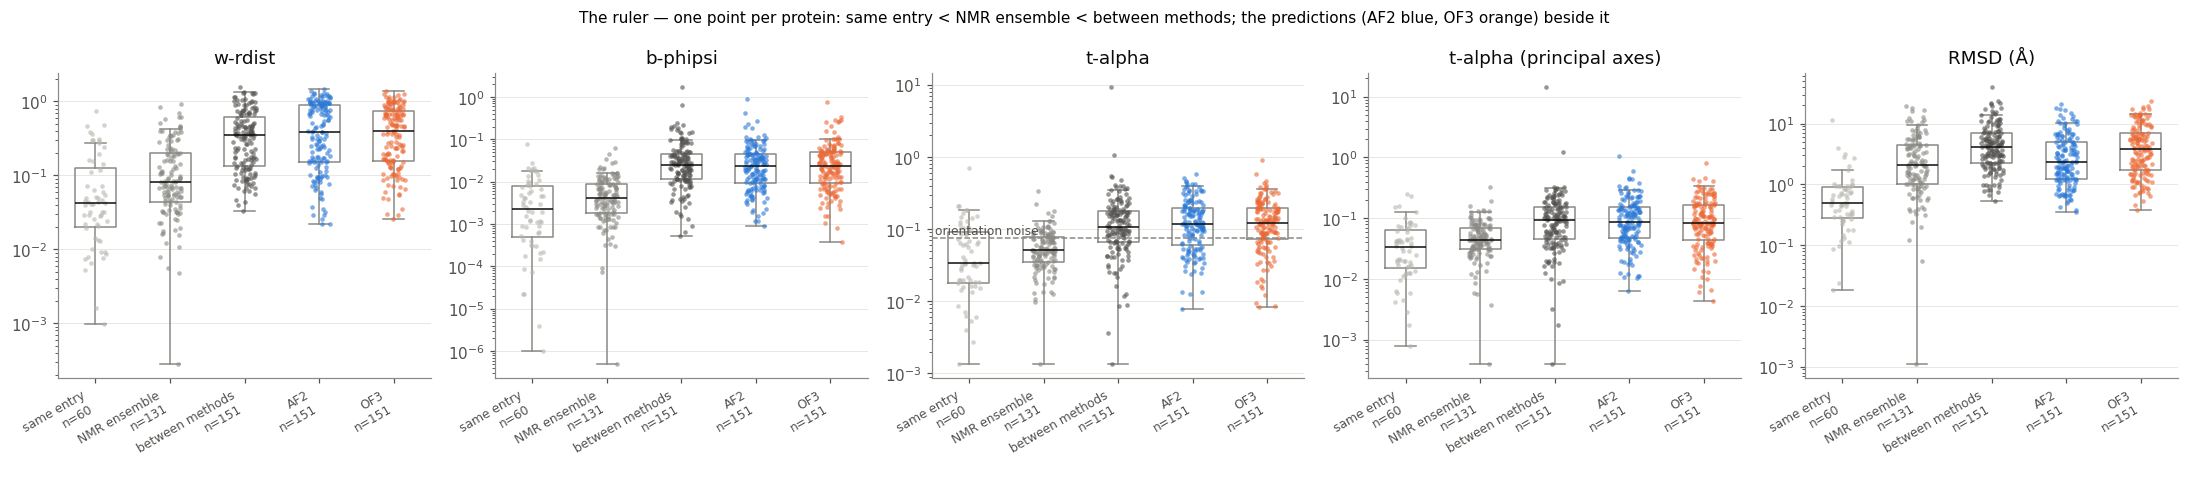

In [10]:
panels = [("w_rdist_norm", None), ("b_phipsi", None), ("t_alpha", None), ("rmsd", None)]
if pca_levels is not None:
    panels.insert(3, ("t_alpha_pca", pca_levels))

fig, axes = plt.subplots(1, len(panels), figsize=(4.0 * len(panels), 4.4))
rng = np.random.default_rng(0)
for ax, (metric, given) in zip(axes, panels):
    long = given if given is not None else baseline_levels(table, copy_summary, metric)
    present = [lvl for lvl in LEVEL_ORDER if lvl in set(long["level"].astype(str))]
    data = [
        long.loc[long["level"].astype(str) == lvl, "value"].to_numpy(dtype=float)
        for lvl in present
    ]
    floor_value = log_floor(*data)
    data = [positive(d, floor_value) for d in data]
    ax.boxplot(
        data,
        widths=0.55,
        showfliers=False,
        medianprops={"color": COLOR["text"]},
        boxprops={"color": COLOR["rule"]},
        whiskerprops={"color": COLOR["rule"]},
        capprops={"color": COLOR["rule"]},
    )
    for k, (lvl, d) in enumerate(zip(present, data), start=1):
        ax.scatter(
            k + rng.uniform(-0.15, 0.15, len(d)),
            d,
            s=9,
            color=COLOR[lvl],
            alpha=0.6,
            linewidths=0,
            zorder=2,
        )
    if metric == "t_alpha" and summary.get("orientation_floor_median") is not None:
        ax.axhline(
            summary["orientation_floor_median"], color=COLOR["rule"], lw=1, ls="--"
        )
        ax.annotate(
            "orientation noise",
            (0.55, summary["orientation_floor_median"]),
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=8,
            color=COLOR["muted"],
        )
    ax.set_yscale("log")
    ax.set_xticks(
        range(1, len(present) + 1),
        [f"{lvl}\nn={len(d)}" for lvl, d in zip(present, data)],
        fontsize=8,
        rotation=30,
        ha="right",
    )
    ax.set_title(LABEL[metric])
    ax.grid(axis="x", visible=False)
fig.suptitle(
    "The ruler — one point per protein: same entry < NMR ensemble < between methods; the predictions (AF2 blue, OF3 orange) beside it",
    fontsize=10,
)
fig.tight_layout()
save(fig, "reference_levels")

---
## 4. How the metrics relate

Spearman correlation between the metrics over proteins, for the experimental variability and for the
AF2 distances. Metrics that are strongly correlated carry the same information; weakly correlated ones
see different aspects of the structures — or, for t-alpha, partly noise (section 2b). Notebook 05
quantifies the overlap with Information Imbalance.

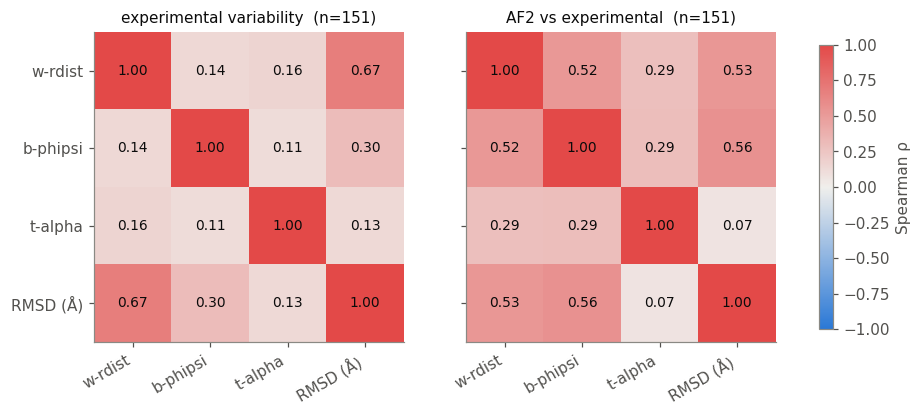

In [11]:
from matplotlib.colors import LinearSegmentedColormap

METRICS = ["w_rdist_norm", "b_phipsi", "t_alpha", "rmsd"]
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#2a78d6", "#f0efec", "#e34948"]
)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, (title, q) in zip(
    axes, [("experimental variability", "exp"), ("AF2 vs experimental", "af2")]
):
    corr = table[[f"{m}__{q}" for m in METRICS]].corr(method="spearman")
    n = int(table[[f"{m}__{q}" for m in METRICS]].dropna().shape[0])
    im = ax.imshow(corr.to_numpy(), cmap=DIVERGING, vmin=-1, vmax=1)
    ax.set_xticks(
        range(len(METRICS)), [LABEL[m] for m in METRICS], rotation=30, ha="right"
    )
    ax.set_yticks(range(len(METRICS)), [LABEL[m] for m in METRICS])
    for i in range(len(METRICS)):
        for j in range(len(METRICS)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=COLOR["text"],
            )
    ax.set_title(f"{title}  (n={n})", fontsize=10)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="Spearman ρ")
save(fig, "metric_correlation_per_protein")
summary["rho_w_rdist_rmsd_exp"] = float(
    table[["w_rdist_norm__exp", "rmsd__exp"]].corr(method="spearman").iloc[0, 1]
)

---
## 5. What the ruler can resolve

*Indicative: this reading describes one run of the pipeline. It is not a final result and holds only as far as the outputs above show it.*

The numbers below are computed from the sections above. Read them as the resolution of the ruler
that notebook 04 uses:

* **Correspondence** — the pipeline computes Machaon's metrics, and none of them pairs residues.
* **Coverage** — whole-chain metrics (w-rdist above all) include the residues one chain lacks. A
  difference between two structures of the same protein is then part conformation, part coverage;
  coverage-matched pairs show how much of the experimental variability is coverage.
* **Orientation** — Machaon's t-alpha carries orientation noise of about the size of the differences
  between methods. Its values between structures of the same protein are therefore close to its noise
  floor; the principal-axes variant shows what is left without it.
* **Levels** — same entry < NMR ensemble < between methods: the experimental variability that the
  predictions are compared with is the loosest of the three references, and it mixes method,
  context and coverage.

In [12]:
def fmt(key, spec=".3f", unit=""):
    value = summary.get(key)
    return "n/a" if value is None else format(value, spec) + unit


lv = summary.get("levels", {})
lines = [
    f"Machaon cross-check: largest difference {fmt('machaon_max_abs_diff', '.1e')}; residues shuffled: largest "
    f"metric {fmt('shuffle_max_metric', '.1g')}, RMSD {fmt('shuffle_rmsd', '.1f', ' Å')}.",
    f"Coverage: Spearman ρ with the length gap — experimental pairs w-rdist {fmt('rho_w_rdist_exp', '.2f')} vs RMSD "
    f"{fmt('rho_rmsd_exp', '.2f')}; prediction pairs w-rdist {fmt('rho_w_rdist_af2', '.2f')} vs RMSD {fmt('rho_rmsd_af2', '.2f')}. "
    f"NMR–cryo-EM w-rdist {fmt('nmr_cryoem_w_rdist_all')} → {fmt('nmr_cryoem_w_rdist_matched')} on coverage-matched pairs; "
    f"removing 5 % of residues gives a median w-rdist of {fmt('truncation_5pct_w_rdist_median')}.",
    f"Orientation: t-alpha of a chain against itself, rotated: median {fmt('orientation_floor_median')} "
    f"(largest {fmt('orientation_floor_max', '.2f')}); median t-alpha between methods {fmt('t_alpha_between_methods')}.",
]
if lv:
    lines.append(
        "Levels (w-rdist): "
        + " < ".join(
            f"{k} {v['w_rdist_norm']:.3f}"
            for k, v in lv.items()
            if k in ("same entry", "NMR ensemble", "between methods")
        )
        + " | predictions: "
        + ", ".join(
            f"{k} {v['w_rdist_norm']:.3f}" for k, v in lv.items() if k in ("AF2", "OF3")
        )
    )
for line in lines:
    print("•", line)
if any("n/a" in line for line in lines):
    print("  (n/a: needs the structure files in data/)")
with open("results/calibration_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("saved results/calibration_summary.json")

• Machaon cross-check: largest difference 3.4e-07; residues shuffled: largest metric 6e-32, RMSD 35.5 Å.
• Coverage: Spearman ρ with the length gap — experimental pairs w-rdist 0.57 vs RMSD 0.30; prediction pairs w-rdist 0.71 vs RMSD -0.02. NMR–cryo-EM w-rdist 0.329 → 0.172 on coverage-matched pairs; removing 5 % of residues gives a median w-rdist of 0.354.
• Orientation: t-alpha of a chain against itself, rotated: median 0.074 (largest 0.55); median t-alpha between methods 0.095.
• Levels (w-rdist): same entry 0.042 < NMR ensemble 0.081 < between methods 0.348 | predictions: AF2 0.387, OF3 0.396
saved results/calibration_summary.json
